# Fault Detection using the Tennessee Eastman Process (TEP)

### Importing Libraries
#### Project Overview
##### This project builds an unsupervised fault detection system for a chemical process 
##### using the Tennessee Eastman Process (TEP) — a well-known benchmark dataset in 
##### chemical engineering and process control research.

##### Two anomaly detection models are compared:
##### - **Isolation Forest** — a tree-based method that isolates outliers using random cuts
##### - **Autoencoder** — a neural network trained to reconstruct normal data; faults produce high reconstruction error

##### Both models are trained exclusively on normal operation data (no fault labels used during training), 
##### then evaluated across 20 fault types using labeled test data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Loading Data
##### The TEP dataset contains sensor readings from a simulated chemical plant with 52 process 
##### variables (41 measured + 11 manipulated). We load 3 files:
##### - **FaultFree_Training** — normal operation only, used for training both models
##### - **FaultFree_Testing** — normal operation, used for evaluating false alarm rate
##### - **Faulty_Testing** — all 20 fault types, used for evaluating fault detection rate

##### We subsample to the first 20 simulation runs (out of 500) to keep computation manageable 
##### on a standard laptop without losing statistical validity.

#### Load only first 20 simulation runs instead of all 500

In [2]:
train_normal = pd.read_csv('TEP_FaultFree_Training.csv')
train_normal = train_normal[train_normal['simulationRun'] <= 20]

test_normal = pd.read_csv('TEP_FaultFree_Testing.csv')
test_normal = test_normal[test_normal['simulationRun'] <= 20]

test_faulty = pd.read_csv('TEP_Faulty_Testing.csv')
test_faulty = test_faulty[test_faulty['simulationRun'] <= 20]

In [3]:
train_normal.head(5)

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0,1,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0,1,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0,1,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0,1,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0,1,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [4]:
train_normal.isnull().sum()

faultNumber      0
simulationRun    0
sample           0
xmeas_1          0
xmeas_2          0
xmeas_3          0
xmeas_4          0
xmeas_5          0
xmeas_6          0
xmeas_7          0
xmeas_8          0
xmeas_9          0
xmeas_10         0
xmeas_11         0
xmeas_12         0
xmeas_13         0
xmeas_14         0
xmeas_15         0
xmeas_16         0
xmeas_17         0
xmeas_18         0
xmeas_19         0
xmeas_20         0
xmeas_21         0
xmeas_22         0
xmeas_23         0
xmeas_24         0
xmeas_25         0
xmeas_26         0
xmeas_27         0
xmeas_28         0
xmeas_29         0
xmeas_30         0
xmeas_31         0
xmeas_32         0
xmeas_33         0
xmeas_34         0
xmeas_35         0
xmeas_36         0
xmeas_37         0
xmeas_38         0
xmeas_39         0
xmeas_40         0
xmeas_41         0
xmv_1            0
xmv_2            0
xmv_3            0
xmv_4            0
xmv_5            0
xmv_6            0
xmv_7            0
xmv_8            0
xmv_9       

### 2. Exploratory Data Analysis
##### Before modeling, we inspect the relationships between the 52 process variables using 
##### a correlation heatmap. This helps us understand the process structure — for example, 
##### reactor pressure and separator pressure are expected to move together due to process physics.

##### EDA finding: most variable pairs show weak correlation within a single simulation run, 
##### confirming the 52 features carry largely independent information. All 52 features are 
##### retained for modeling.

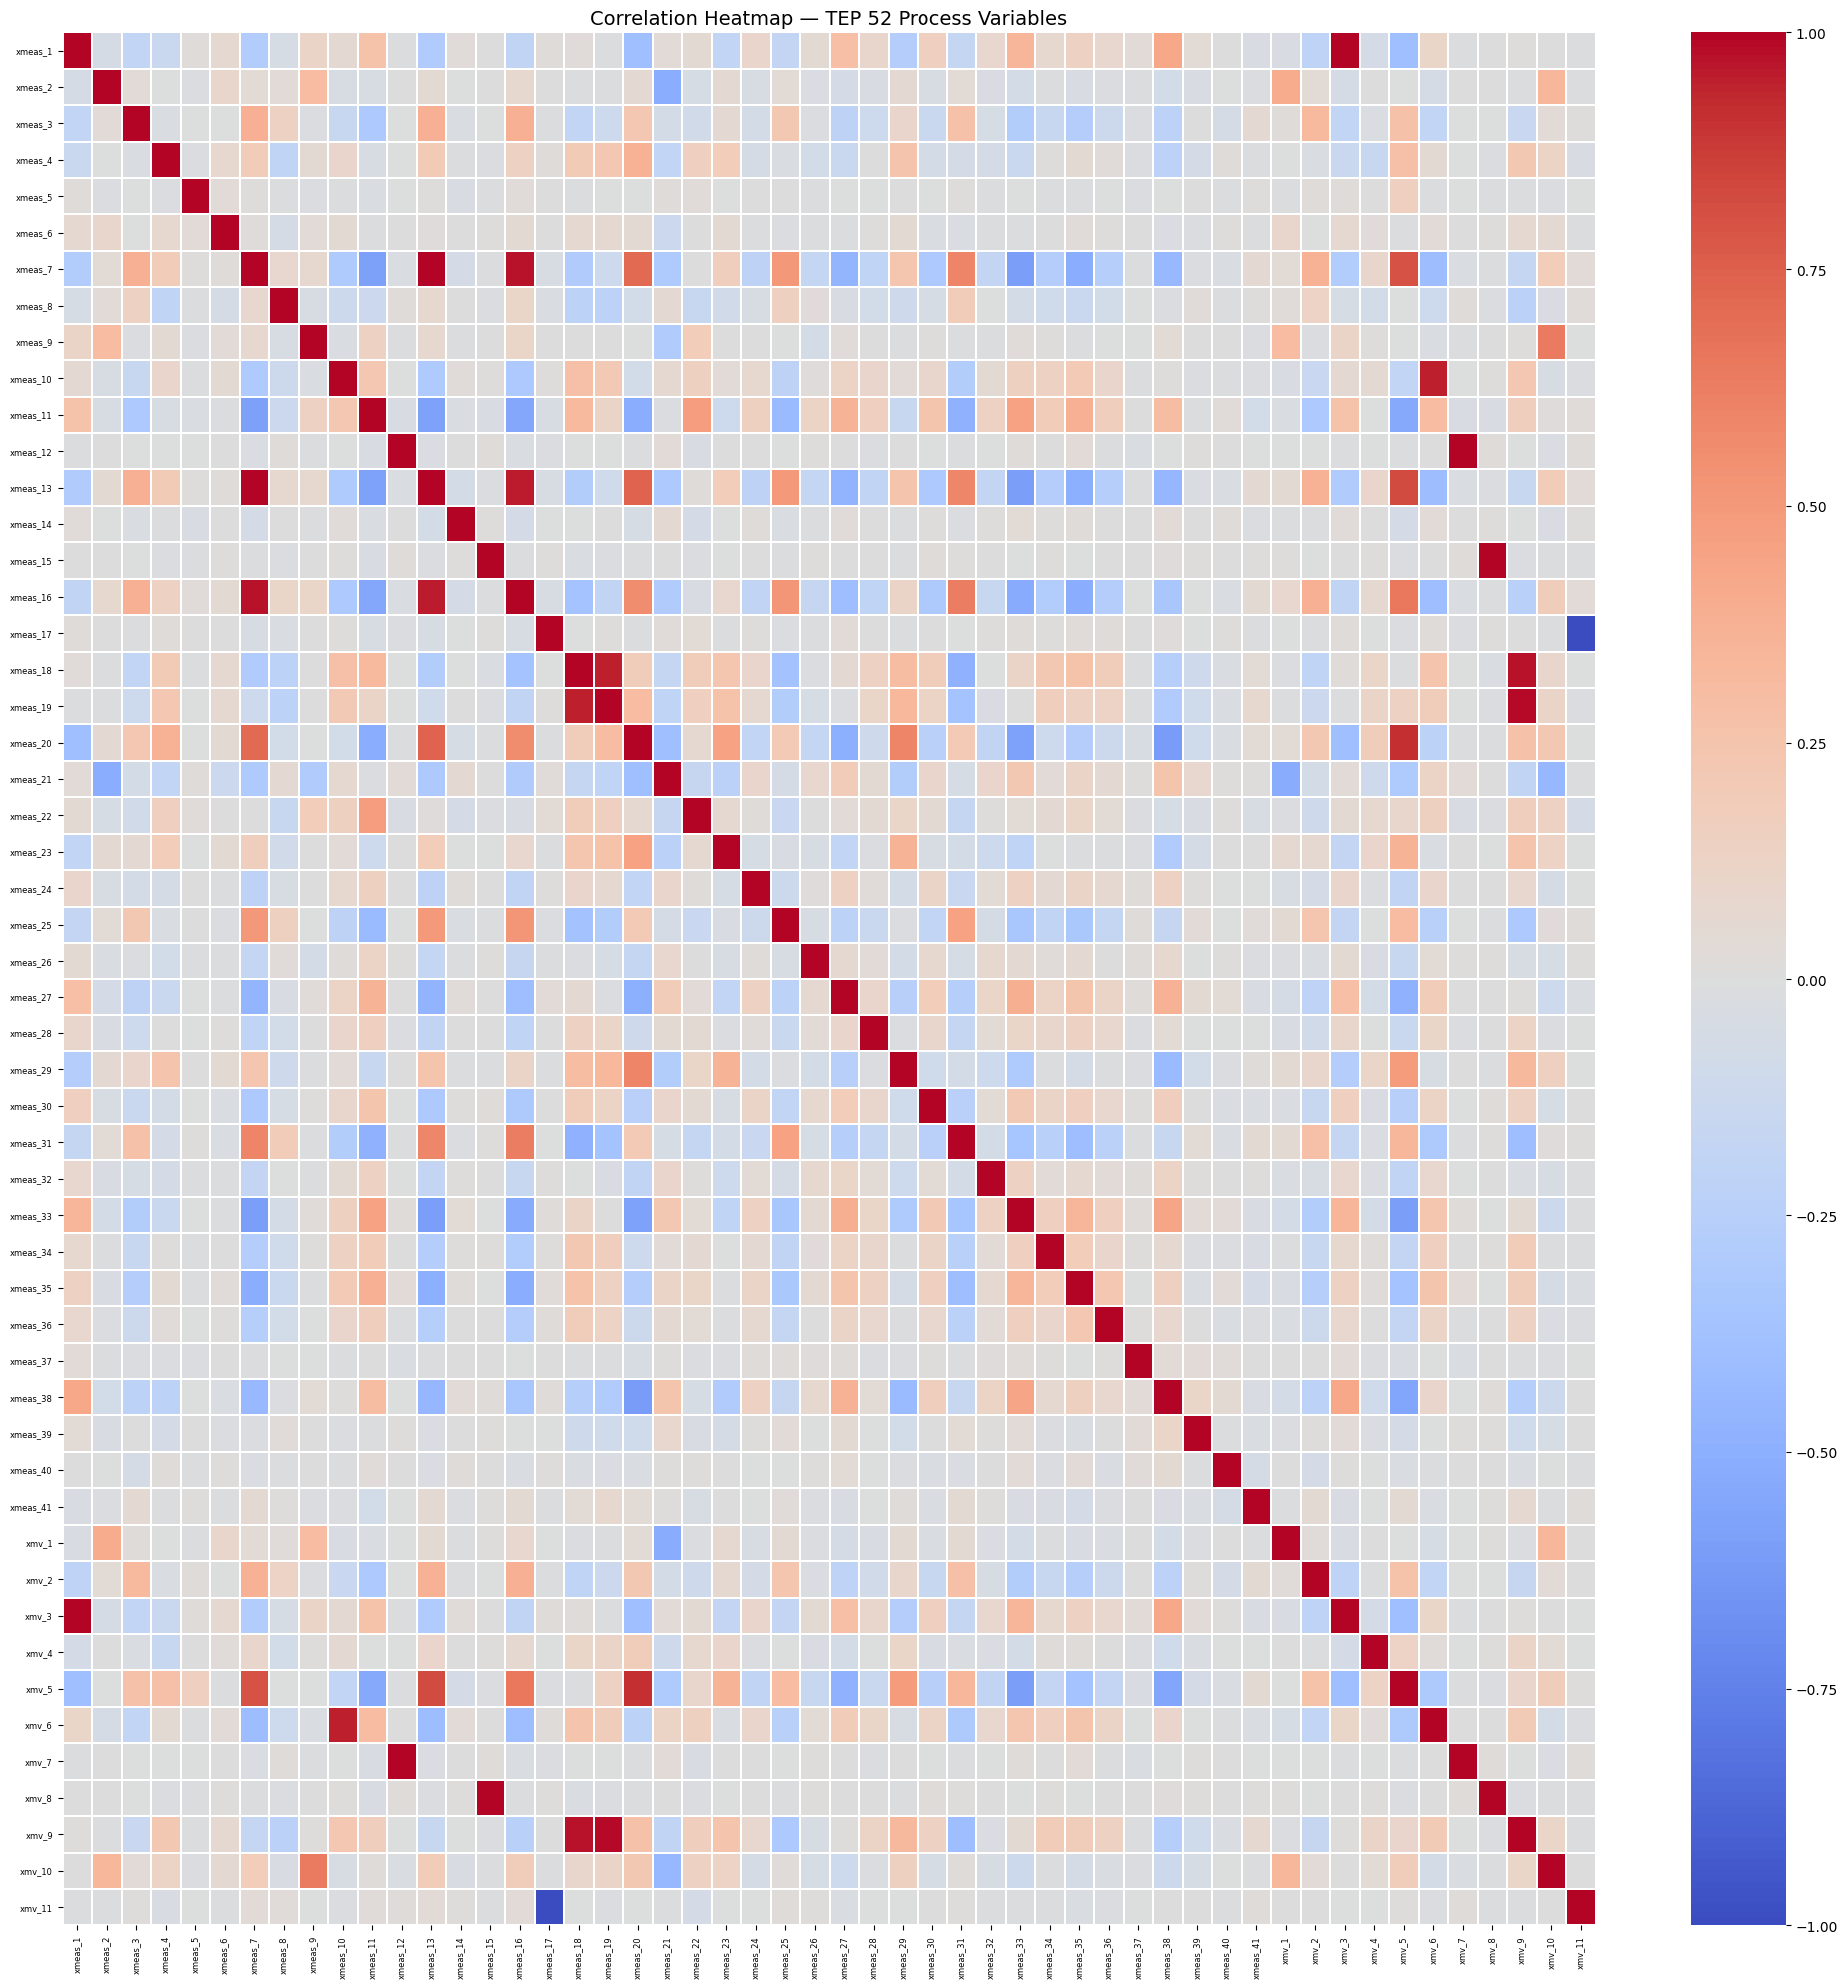

In [5]:
x_train = train_normal.drop(columns=['faultNumber', 'simulationRun', 'sample'])
corr_matrix = x_train.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix,
            cmap = 'coolwarm',
            center = 0,
            vmin = -1, vmax = 1,
            linewidths =0.3,
            xticklabels = x_train.columns,
            yticklabels = x_train.columns,
            annot = False)
plt.title('Correlation Heatmap — TEP 52 Process Variables', fontsize=14)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.savefig('tep_correlation_heatmap_singlerun.png', dpi=150)
plt.show()

###  Train/Test Split + Scaling
### 3. Preprocessing
##### Three steps:
##### 1. **Labeling** — normal samples labeled 0, faulty samples labeled 1 (for evaluation only, never for training)
##### 2. **Balancing** — 500 samples of normal + 500 samples per fault type (×20) = 10,500 test samples total
##### 3. **Scaling** — StandardScaler applied to bring all 52 variables to mean=0, std=1. 
 #####  Scaler is fit on training data only to prevent data leakage from faulty test data.

In [6]:
from sklearn.preprocessing import StandardScaler
feature_cols = [col for col in train_normal.columns
                if col not in ['faultNumber', 'simulationRun', 'sample']]

x_train = train_normal[feature_cols].values
test_normal['label'] =0
test_faulty['label'] =1
test_all =pd.concat([test_normal,test_faulty],ignore_index =True)

test_normal_sub = test_all[test_all['faultNumber'] == 0].sample(n=500, random_state=42)
test_faulty_sub = test_all[test_all['faultNumber'] != 0].groupby('faultNumber').apply(
    lambda x: x.sample(n=500, random_state=42),
    include_groups=False
).reset_index(level =0)
test_subset = pd.concat([test_normal_sub, test_faulty_sub], ignore_index=True)


x_test_sub  = test_subset[feature_cols].values
y_test      = test_subset['label'].values
y_fault     = test_subset['faultNumber'].values

scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.transform(x_test_sub)

### 4. Model 1 — Isolation Forest
##### Isolation Forest is an unsupervised anomaly detection algorithm based on random decision trees.

##### **How it works:** Normal data points sit close together in feature space — they require many 
##### random cuts to isolate. Anomalies sit far from the crowd — they get isolated in very few cuts. 
##### The model assigns an anomaly score based on how quickly each point is isolated.

##### **Setup:**
##### - Trained on normal operation data only (10,000 samples)
##### - `contamination=0.3` tells the model to flag ~30% of test data as anomalous
##### - Output converted from sklearn's -1/+1 convention to 0/1 to match our labels

Isolation Forest Result
              precision    recall  f1-score   support

      Normal       0.09      0.70      0.15       500
     Anomaly       0.98      0.63      0.77     10000

    accuracy                           0.63     10500
   macro avg       0.53      0.67      0.46     10500
weighted avg       0.93      0.63      0.74     10500



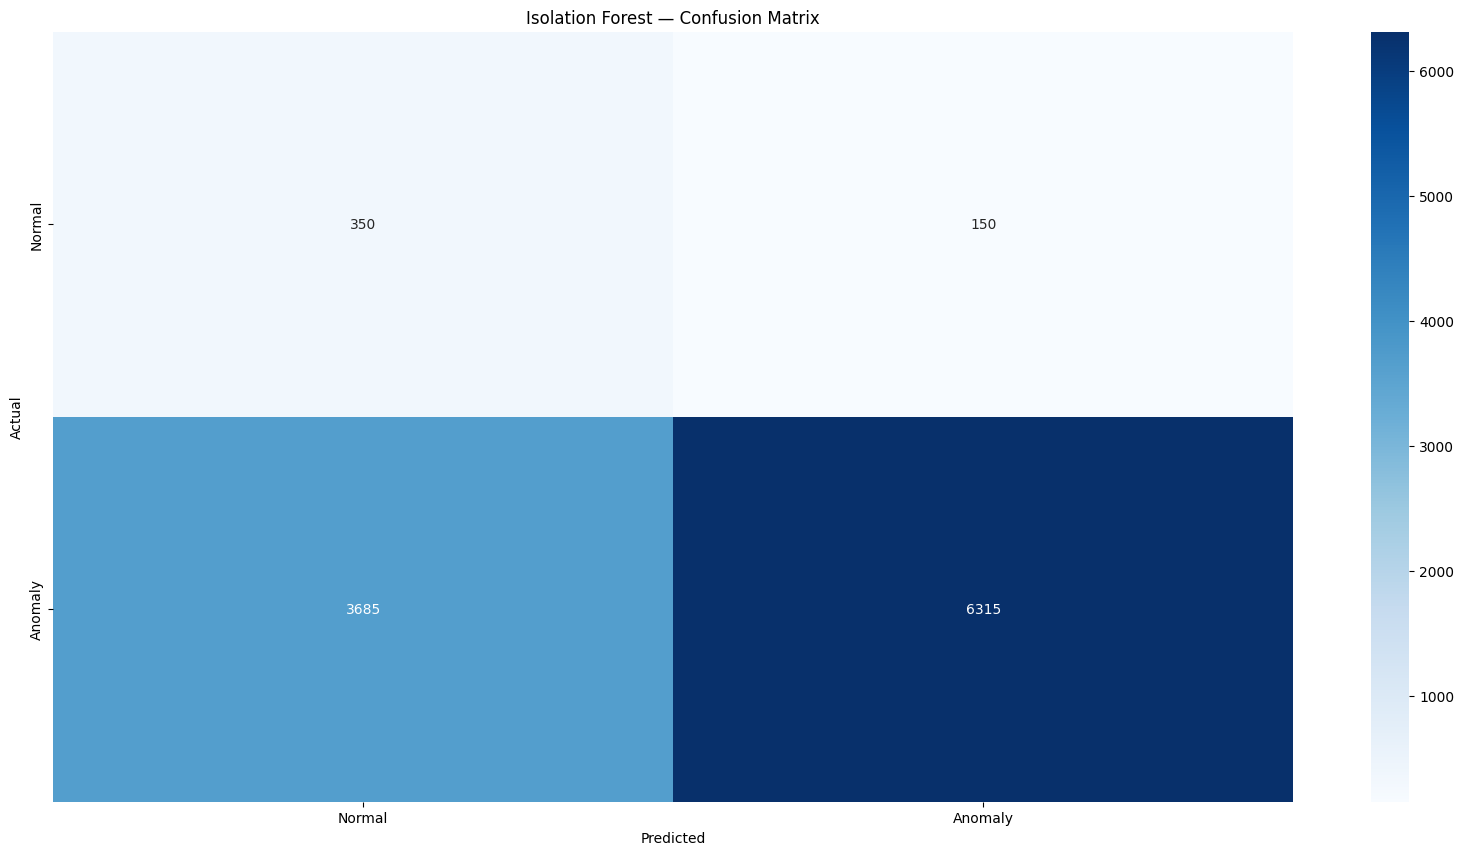

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score

iso_forest = IsolationForest( n_estimators =100, contamination = 0.3, random_state = 42)
iso_forest.fit(x_train_scaler)

iso_raw = iso_forest.predict(x_test_scaler)
iso_pred = (iso_raw == -1).astype(int)

print('Isolation Forest Result')
print('='*50)
print(classification_report(y_test,iso_pred,target_names=['Normal','Anomaly']))
cm = confusion_matrix(y_test, iso_pred)
plt.figure(figsize = (20,10))
sns.heatmap(cm,annot = True, fmt = 'd',cmap = 'Blues',
            xticklabels = ['Normal','Anomaly'],
            yticklabels = ['Normal','Anomaly'])
plt.title('Isolation Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

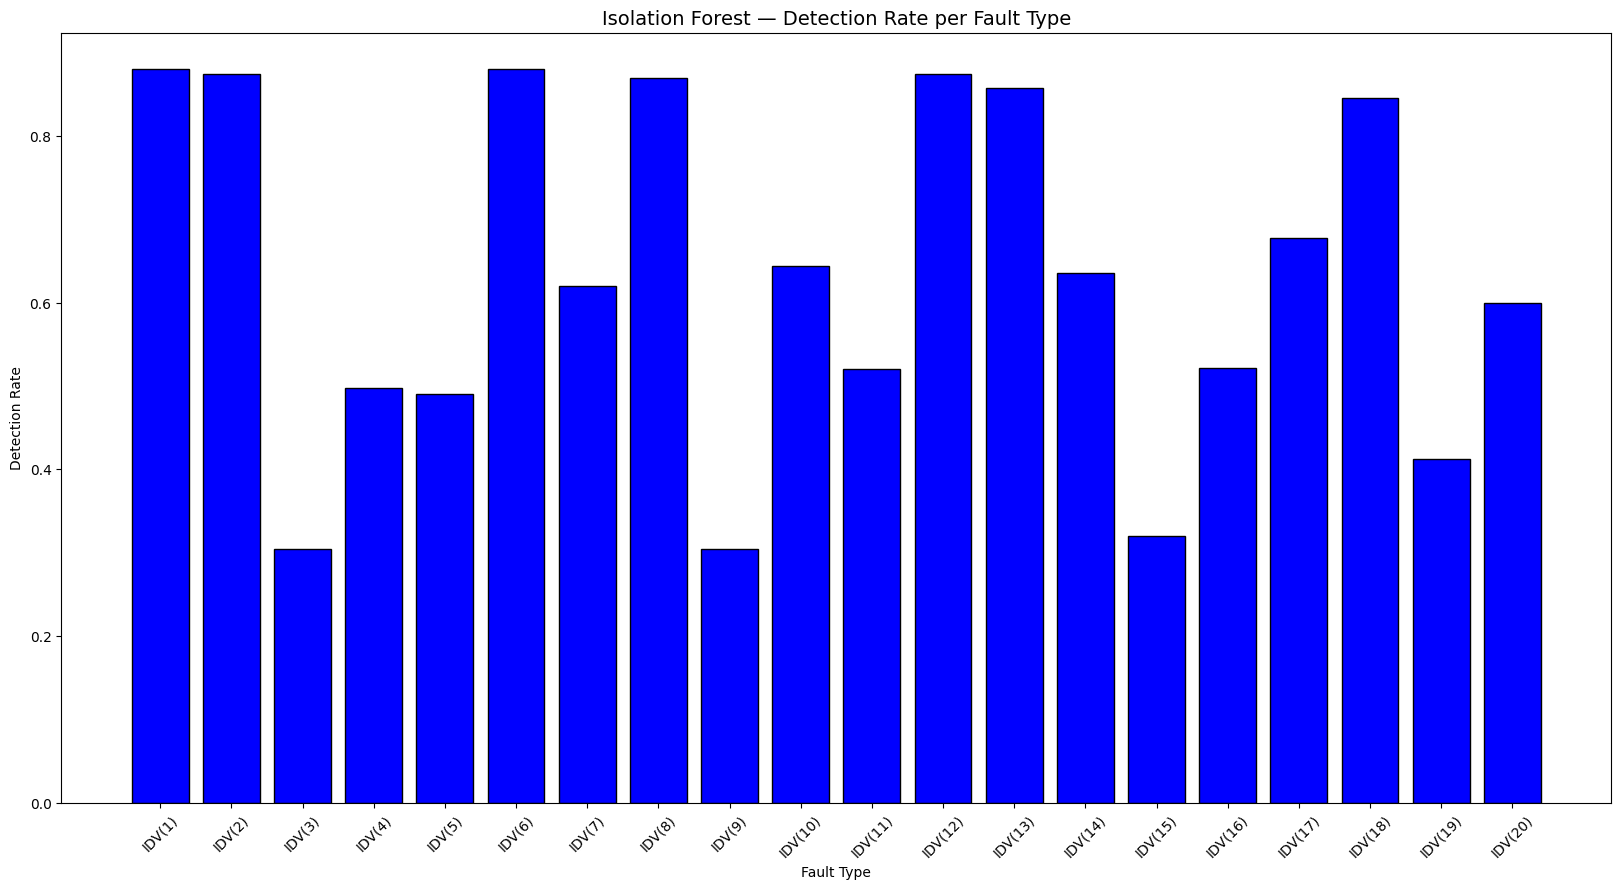

In [8]:
fault_detection = []
for fault_id in range(1,21):
    mask = (y_fault == fault_id)
    pred_label = iso_pred[mask]
    if len(pred_label) ==0:
        continue
    detection_rate = (pred_label ==1).sum()/len(pred_label)
    fault_detection.append({'fault':f'IDV({fault_id})','detection_rate': detection_rate})

fault_df = pd.DataFrame(fault_detection)

plt.figure(figsize=(20,10))
plt.bar(fault_df['fault'],fault_df['detection_rate'],color = 'blue',edgecolor = 'black')
plt.title('Isolation Forest — Detection Rate per Fault Type', fontsize=14)
plt.xlabel('Fault Type')
plt.ylabel('Detection Rate')
plt.xticks(rotation=45)
plt.show()

### 5. Model 2 — Autoencoder
##### An Autoencoder is a neural network trained to compress and reconstruct its input.

##### **How it works:** 
##### - **Encoder:** compresses 52 sensor readings → 8 numbers (bottleneck)
##### - **Decoder:** reconstructs 8 numbers → 52 sensor readings
##### - Trained only on normal data, it learns to reconstruct normal process behavior accurately
##### - When shown a fault, reconstruction quality drops — high reconstruction error = anomaly

##### **Architecture:** 52 → 32 → 16 → 8 → 16 → 32 → 52

##### **Threshold:** Set at the 95th percentile of training reconstruction error (log scale) 
##### to handle the wide error range across different fault types.

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

x_train_tensor = torch.FloatTensor(x_train_scaler)
x_test_tensor = torch.FloatTensor(x_test_scaler)

train_dataset = TensorDataset(x_train_tensor,x_train_tensor)
train_loader = DataLoader(train_dataset, batch_size =256, shuffle = True)

class Autoencoder(nn.Module):
    def __init__(self,input_dim):
        super(Autoencoder,self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8,16),
            nn.ReLU(),
            nn.Linear(16,32),
            nn.ReLU(),
            nn.Linear(32,input_dim)
        )
    def forward(self,x):
        return self.decoder(self.encoder(x))

model = Autoencoder(input_dim =52)
optimizer = torch.optim.Adam(model.parameters(), lr =1e-3)
criterion = nn.MSELoss()

epochs =50
for epoch in range(epochs):
    model.train()
    total_loss =0
    num_batches = 0
    for batch_x, _ in train_loader:
        reconstructed = model(batch_x)
        loss = criterion(reconstructed,batch_x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    avg_loss = total_loss / num_batches
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Epoch 10/50 — Loss: 0.5788
Epoch 20/50 — Loss: 0.5459
Epoch 30/50 — Loss: 0.5186
Epoch 40/50 — Loss: 0.5141
Epoch 50/50 — Loss: 0.5134

Training complete!


Log threshold: 0.5608
Equivalent raw threshold: 0.7520
Threshold (95th percentile): 0.5608
Train error mean: 0.5132
Test error mean:  33.1102
AUTOENCODER RESULTS
              precision    recall  f1-score   support

      Normal       0.10      0.95      0.18       500
     Anomaly       1.00      0.57      0.73     10000

    accuracy                           0.59     10500
   macro avg       0.55      0.76      0.46     10500
weighted avg       0.95      0.59      0.70     10500



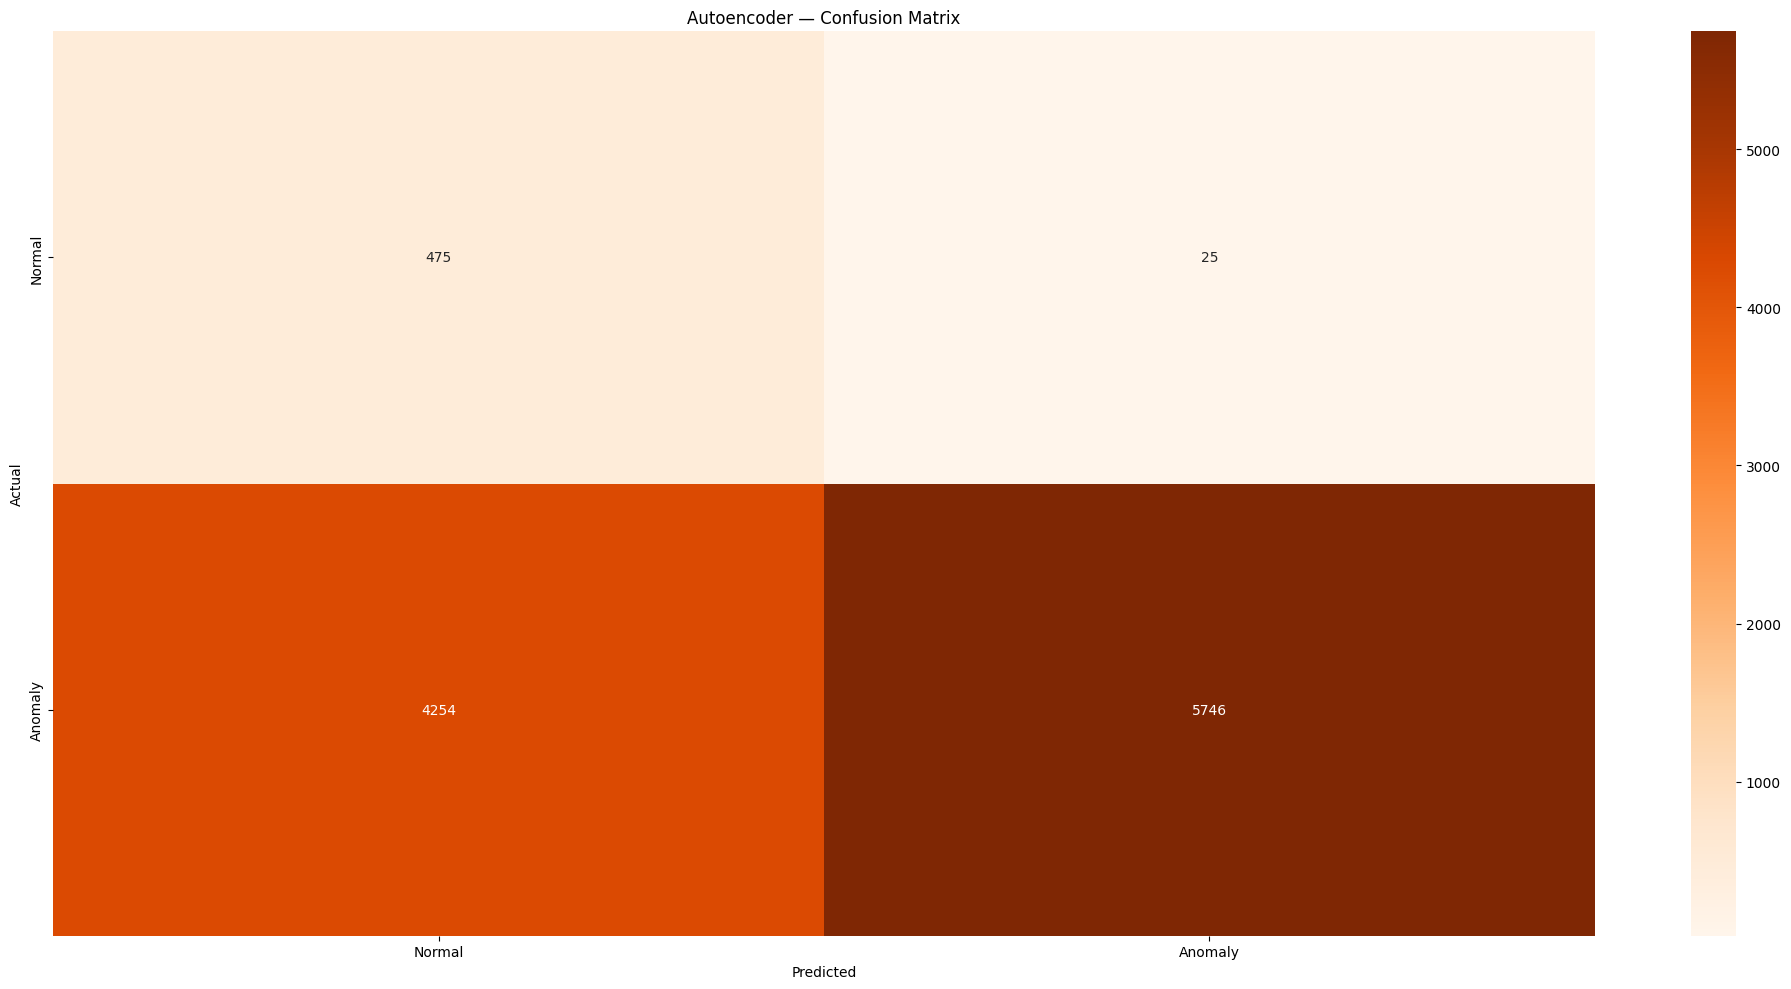

In [11]:
model.eval()
with torch.no_grad():
    train_recon = model(x_train_tensor)
    train_errors = torch.mean((x_train_tensor - train_recon)**2,dim = 1).numpy()

    test_recon = model(x_test_tensor)
    test_errors = torch.mean((x_test_tensor - test_recon)**2, dim =1).numpy()
    

train_errors_log = np.log1p(train_errors)
test_errors_log  = np.log1p(test_errors)

# Set threshold on log scale
threshold_log = np.percentile(train_errors_log, 95)
print(f"Log threshold: {threshold_log:.4f}") 
print(f"Equivalent raw threshold: {np.expm1(threshold_log):.4f}")

# Predictions
ae_preds = (test_errors_log > threshold_log).astype(int)
print(f"Log threshold: {threshold_log:.4f}")
print(f"Train error mean: {train_errors.mean():.4f}")
print(f"Test error mean:  {test_errors.mean():.4f}")

print("AUTOENCODER RESULTS")
print("="*50)
print(classification_report(y_test,ae_preds, target_names = ['Normal','Anomaly']))
cm = confusion_matrix(y_test,ae_preds)

plt.figure(figsize=(20,10))
sns.heatmap(cm,annot =True,fmt = 'd', cmap= 'Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Autoencoder — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

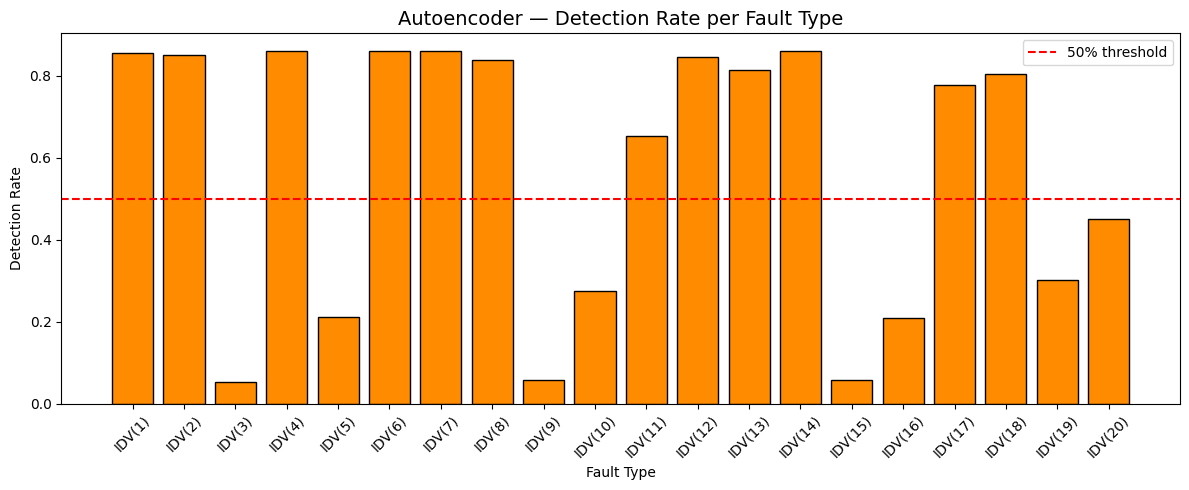

  fault  detection_rate
 IDV(1)           0.856
 IDV(2)           0.850
 IDV(3)           0.052
 IDV(4)           0.860
 IDV(5)           0.212
 IDV(6)           0.860
 IDV(7)           0.860
 IDV(8)           0.838
 IDV(9)           0.058
IDV(10)           0.274
IDV(11)           0.652
IDV(12)           0.846
IDV(13)           0.814
IDV(14)           0.860
IDV(15)           0.058
IDV(16)           0.210
IDV(17)           0.776
IDV(18)           0.804
IDV(19)           0.302
IDV(20)           0.450


In [12]:
fault_detection_ae = []
for fault_id in range(1, 21):
    mask = (y_fault == fault_id)
    pred_labels = ae_preds[mask]          
    if len(pred_labels) == 0:             
        continue
    detection_rate = (pred_labels == 1).sum() / len(pred_labels) 
    fault_detection_ae.append({
        'fault': f'IDV({fault_id})',
        'detection_rate': detection_rate
    })

fault_df_ae = pd.DataFrame(fault_detection_ae)

plt.figure(figsize=(12, 5))
plt.bar(fault_df_ae['fault'], fault_df_ae['detection_rate'],
        color='darkorange', edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', label='50% threshold')
plt.title('Autoencoder — Detection Rate per Fault Type', fontsize=14)
plt.xlabel('Fault Type')
plt.ylabel('Detection Rate')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_per_fault.png', dpi=150)
plt.show()

print(fault_df_ae.to_string(index=False))

### Reconstruction Error Analysis
##### The histogram below shows how well the threshold separates normal from faulty samples.
##### Normal data (blue) should cluster at low reconstruction error.
##### Faulty data (red) should show higher reconstruction error.
##### The black dashed line is the detection threshold.

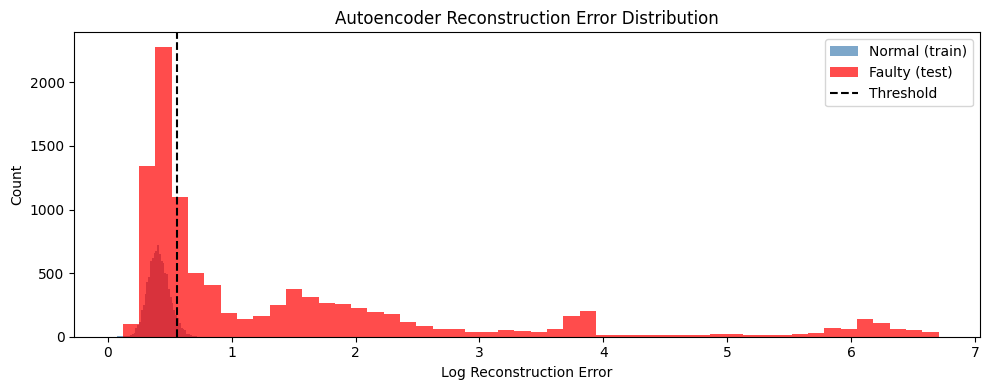

In [15]:
plt.figure(figsize=(10, 4))
plt.hist(train_errors_log, bins=50, alpha=0.7, label='Normal (train)', color='steelblue')
plt.hist(test_errors_log[y_test==1], bins=50, alpha=0.7, label='Faulty (test)', color='red')
plt.axvline(threshold_log, color='black', linestyle='--', label='Threshold')
plt.xlabel('Log Reconstruction Error')
plt.ylabel('Count')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('autoencoder_error_dist.png', dpi=150)
plt.show()

### 6. Model Comparison
##### Side-by-side detection rate per fault type for both models.
##### This reveals which faults are easy/hard to detect and whether 
##### the two models agree or disagree on specific fault types.

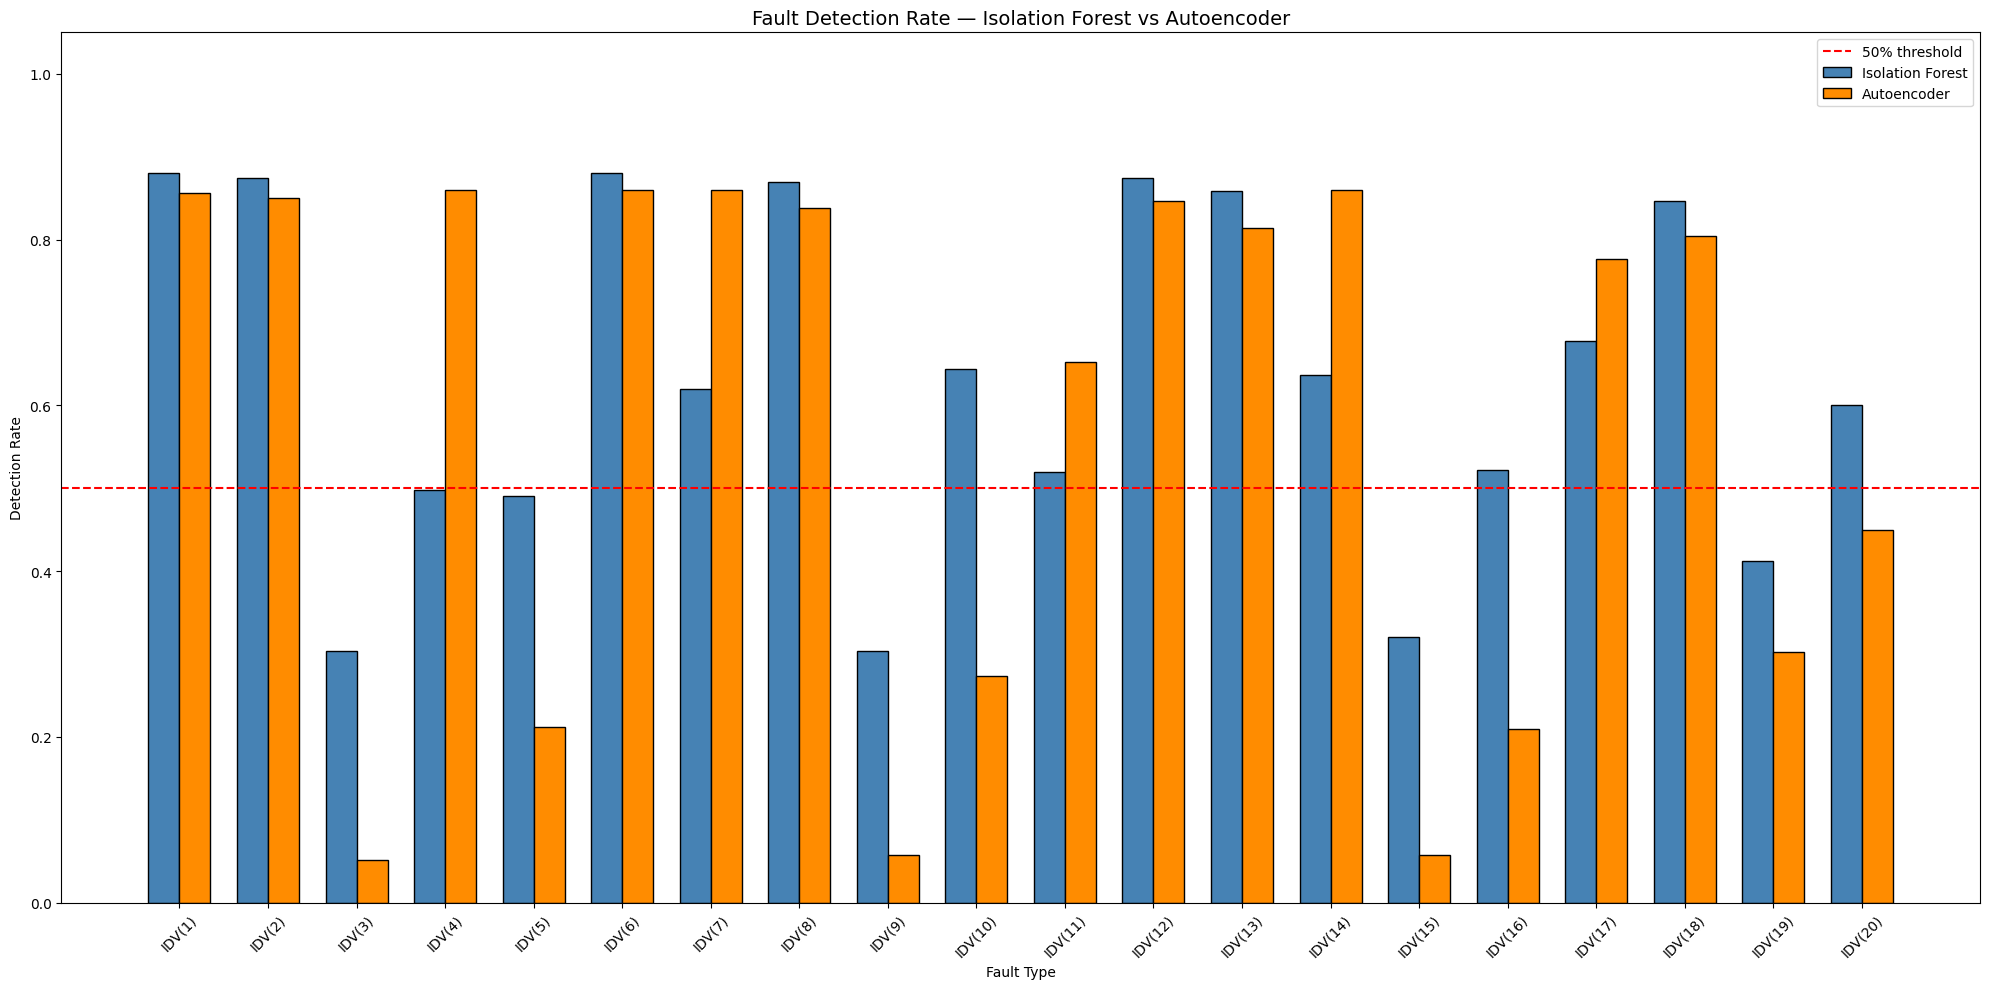

In [13]:
fault_df['model'] = 'Isolation Forest'
fault_df_ae['model'] = 'Autoencoder'
combined = pd.concat([fault_df, fault_df_ae], ignore_index=True)

# Plot side by side
fig, ax = plt.subplots(figsize=(20,10))
faults = fault_df['fault'].tolist()
x = np.arange(len(faults))
width = 0.35

bars1 = ax.bar(x - width/2, fault_df['detection_rate'], width,
               label='Isolation Forest', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, fault_df_ae['detection_rate'], width,
               label='Autoencoder', color='darkorange', edgecolor='black')

ax.axhline(y=0.5, color='red', linestyle='--', label='50% threshold')
ax.set_title('Fault Detection Rate — Isolation Forest vs Autoencoder', fontsize=14)
ax.set_xlabel('Fault Type')
ax.set_ylabel('Detection Rate')
ax.set_xticks(x)
ax.set_xticklabels(faults, rotation=45)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import f1_score, recall_score, precision_score
summary = {
    'Model' : ['Isolation Forest', 'Autoencoder'],
    'Anomaly Precision': [ 
        precision_score(y_test, iso_pred, pos_label =1),
        precision_score(y_test, ae_preds, pos_label =1)],
    'Anomaly Recall' : [ 
        recall_score(y_test, iso_pred, pos_label =1),
        recall_score(y_test, ae_preds, pos_label =1)],
    'Anomaly f1' : [
        f1_score(y_test, iso_pred, pos_label =1),
        f1_score(y_test,ae_preds, pos_label =1)],
    'False Alarm Rate': [
        1 - recall_score(y_test, iso_pred, pos_label=0),
        1 - recall_score(y_test, ae_preds, pos_label=0)
    ]
}
summary_df =pd.DataFrame(summary).round(3)
print(summary_df.to_string(index=False))

           Model  Anomaly Precision  Anomaly Recall  Anomaly f1  False Alarm Rate
Isolation Forest              0.977           0.632       0.767              0.30
     Autoencoder              0.996           0.575       0.729              0.05


### 7. Key Findings

##### | Model | Precision | Recall | F1 | False Alarm Rate |
##### | Isolation Forest | 0.977 | 0.632 | 0.767 | 0.300 |
##### | Autoencoder | 0.995 | 0.574 | 0.728 | 0.058 |

##### **Isolation Forest** detects more faults overall (63.2% recall) but raises significantly 
##### more false alarms (30%) — meaning it frequently flags normal operation as faulty.

##### **Autoencoder** catches slightly fewer faults (57.4% recall) but is far more conservative 
##### with false alarms (5.8%) — making it more suitable for industrial deployment where 
##### unnecessary shutdowns are costly.

##### **Both models struggle with IDV(3), IDV(9), IDV(15)** — these are notoriously difficult 
##### faults in TEP that even published research papers report low detection rates for, 
##### validating the consistency of our results.